# DPO Learning Project — base model → aligned model, hands-on
Run top-to-bottom on a free Colab T4 (Runtime → Change runtime type → T4 GPU).
Four stages: **baseline eval → DPO training → re-eval → quantization comparison**.
See `README.md` in the project folder for the full runbook and what to observe at each stage.

In [ ]:
!pip install -q transformers>=4.48 trl>=0.15 peft datasets accelerate bitsandbytes lm-eval sentencepiece
print('installs done — restart runtime if prompted, then continue')

installs done — restart runtime if prompted, then continue


## Stage 0 — config & helpers

In [ ]:
import json, torch
from pathlib import Path
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

MODEL_ID = 'Qwen/Qwen2.5-0.5B'   # ungated base; fallback: 'TinyLlama/TinyLlama-1.1B'
OUT = Path('./dpo_project'); OUT.mkdir(exist_ok=True)
MMLU_TASKS = ['mmlu_high_school_mathematics','mmlu_elementary_mathematics','mmlu_college_computer_science']
MMLU_LIMIT = 30
PROMPTS = [
  'Explain why the sky is blue in one short paragraph.',
  'Write a polite email declining a meeting invitation.',
  'What are three tips for debugging a slow Python program?',
  'Summarize the plot of Romeo and Juliet in two sentences.',
  'Is it safe to share my password with tech support? Explain briefly.',
]

def get_tok(mid=MODEL_ID):
    t = AutoTokenizer.from_pretrained(mid, trust_remote_code=True)
    if t.pad_token is None: t.pad_token = t.eos_token
    return t

def save(obj, name):
    p = OUT / name
    p.write_text(json.dumps(obj, indent=2)); print('saved', p)

print('torch', torch.__version__, '| cuda:', torch.cuda.is_available())

torch 2.11.0+cu128 | cuda: True


## Stage 1 — baseline eval of the BASE model
Watch how a raw base model *continues* prompts instead of *answering* them — that's what alignment is about to fix.

In [ ]:
import lm_eval
res = lm_eval.simple_evaluate(model='hf',
    model_args=f'pretrained={MODEL_ID},dtype=float16,trust_remote_code=True',
    tasks=MMLU_TASKS, limit=MMLU_LIMIT, log_samples=True, batch_size=8)
base_mmlu = {t: res['results'][t].get('acc,none') for t in MMLU_TASKS}
print(base_mmlu); save(base_mmlu, 'baseline_mmlu.json')

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.23k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/5 [00:00<?, ? examples/s]

Running loglikelihood requests: 100%|██████████| 360/360 [00:01<00:00, 187.86it/s]


{'mmlu_high_school_mathematics': 0.3333333333333333, 'mmlu_elementary_mathematics': 0.3333333333333333, 'mmlu_college_computer_science': 0.43333333333333335}
saved dpo_project/baseline_mmlu.json


In [ ]:
tok = get_tok()
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float16, device_map='auto', trust_remote_code=True).eval()
base_gens = []
with torch.inference_mode():
    for p in PROMPTS:
        inp = tok(p, return_tensors='pt').to(model.device)
        g = model.generate(**inp, max_new_tokens=120, do_sample=False, pad_token_id=tok.eos_token_id)
        txt = tok.decode(g[0][inp['input_ids'].shape[1]:], skip_special_tokens=True)
        base_gens.append({'prompt': p, 'generation': txt})
        print(f'PROMPT: {p}\nGEN: {txt}\n' + '-'*60)
save(base_gens, 'baseline_generations.json')
del model; torch.cuda.empty_cache()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

PROMPT: Explain why the sky is blue in one short paragraph.
GEN:  The sky is blue because it reflects sunlight, which is a type of electromagnetic radiation. When sunlight hits the Earth's atmosphere, it is scattered and bent by the molecules and particles in the air. This scattering of light causes it to be dispersed into different colors, including blue. The blue light is then absorbed by the Earth's surface, which is why we see the sky as blue.
------------------------------------------------------------
PROMPT: Write a polite email declining a meeting invitation.
GEN:  Dear [Recipient's Name],

I hope this email finds you well. I am writing to express my disappointment and frustration with the recent invitation to a meeting that I have not yet attended. As a matter of courtesy and respect, I would like to decline this invitation.

I understand that you have arranged for this meeting, and I appreciate your efforts to make it a positive experience for all involved. However, I feel th

## Stage 2 — DPO fine-tuning (TRL + LoRA)
**Watch `rewards/margins`** in the output: the chosen-vs-rejected implicit-reward gap. Rising margin = the model is learning the preference.
`ref_model=None` means TRL builds a frozen reference from the base weights (with LoRA, the adapter is simply disabled for the reference) — no second model copy in VRAM.

In [ ]:
def as_text(msgs):
    return msgs.strip() if isinstance(msgs, str) else tok.apply_chat_template(msgs, tokenize=False).strip()

def split_prompt(conv):
    # dpo-mix-7k has no 'prompt' column: the prompt is the shared prefix
    # of the chosen/rejected conversations (everything but the last message)
    if isinstance(conv, str):
        return [], conv
    if isinstance(conv, list) and len(conv) > 1:
        return conv[:-1], conv[-1:]
    return [], conv

ds = load_dataset('argilla/dpo-mix-7k', split='train')
print('raw columns:', ds.column_names)
def fmt(b):
    prompts, chosens, rejecteds = [], [], []
    for c, r in zip(b['chosen'], b['rejected']):
        p_c, c_last = split_prompt(c)
        p_r, r_last = split_prompt(r)
        p = p_c if p_c else p_r
        prompts.append(as_text(p) if p else '')
        chosens.append(as_text(c_last))
        rejecteds.append(as_text(r_last))
    return {'prompt': prompts, 'chosen': chosens, 'rejected': rejecteds}
train_ds = ds.map(fmt, batched=True, remove_columns=ds.column_names)
print(len(train_ds), 'preference pairs | columns:', train_ds.column_names)
print('example prompt:', train_ds[0]['prompt'][:200])
print('example chosen:', train_ds[0]['chosen'][:200])


raw columns: ['dataset', 'chosen', 'rejected', 'chosen_rating', 'rejected_rating']


Map:   0%|          | 0/6750 [00:00<?, ? examples/s]

6750 preference pairs | columns: ['chosen', 'rejected', 'prompt']
example prompt: <|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
Q:Question: how old julio cesar chavez when he fought de la hoya I found the following answer on Google: He holds records for
example chosen: <|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>assistant
 Yes, the information you found on Google is correct. Julio César Chávez holds several records related to world title de


In [ ]:
from peft import LoraConfig, TaskType
from trl import DPOConfig, DPOTrainer

model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float16, device_map='auto', trust_remote_code=True)
args = DPOConfig(output_dir=str(OUT/'dpo_adapter'), beta=0.1,
    per_device_train_batch_size=2, gradient_accumulation_steps=4,   # effective batch 8
    max_steps=500, max_length=512,
    learning_rate=5e-5, lr_scheduler_type='cosine', warmup_steps=50,
    logging_steps=10, save_steps=250, fp16=True,                    # T4: no bf16
    gradient_checkpointing=True, remove_unused_columns=False, report_to='none')
trainer = DPOTrainer(model=model, ref_model=None, args=args, train_dataset=train_ds,
                     processing_class=tok,
                     peft_config=LoraConfig(task_type=TaskType.CAUSAL_LM, r=16, lora_alpha=32,
                         lora_dropout=0.05, target_modules=['q_proj','k_proj','v_proj','o_proj']))
trainer.train()
trainer.save_model(str(OUT/'dpo_adapter')); tok.save_pretrained(str(OUT/'dpo_adapter'))
save(trainer.state.log_history, 'dpo_train_log.json')
print('adapter saved')

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Adding EOS to train dataset:   0%|          | 0/6750 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/6750 [00:00<?, ? examples/s]

Dropping fully truncated examples from train dataset:   0%|          | 0/6750 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Step,Training Loss
10,0.693292
20,0.676924
30,0.648774
40,0.635153
50,0.570188
60,0.737360
70,0.578030
80,0.609855
90,0.633009
100,0.620356


saved dpo_project/dpo_train_log.json
adapter saved


In [ ]:
!pip install -q "torchao>=0.16.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 86.8 MB/s eta 0:00:00


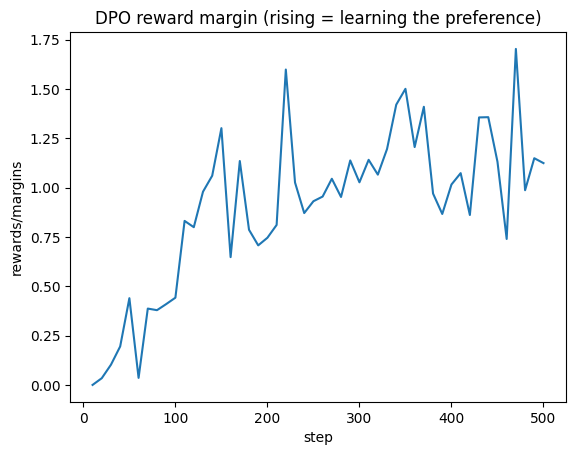

In [ ]:
# Plot the reward margin curve — the single most important diagnostic
import matplotlib.pyplot as plt
log = json.loads((OUT/'dpo_train_log.json').read_text())
steps=[e['step'] for e in log if 'rewards/margins' in e]
marg=[e['rewards/margins'] for e in log if 'rewards/margins' in e]
plt.plot(steps, marg); plt.xlabel('step'); plt.ylabel('rewards/margins')
plt.title('DPO reward margin (rising = learning the preference)'); plt.show()

In [ ]:
# Merge LoRA into base weights -> a plain HF checkpoint for eval
from peft import PeftModel
base = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float16, device_map='cpu', trust_remote_code=True)
merged = PeftModel.from_pretrained(base, str(OUT/'dpo_adapter')).merge_and_unload()
merged.save_pretrained(str(OUT/'dpo_merged')); tok.save_pretrained(str(OUT/'dpo_merged'))
print('merged checkpoint saved')
del base, merged; torch.cuda.empty_cache()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

merged checkpoint saved


## Stage 3 — re-eval the DPO checkpoint
Same harness as stage 1. Compare: generations should now *answer*; MMLU may dip slightly — that's the **alignment tax**.

In [ ]:
MPATH = str(OUT/'dpo_merged')
res = lm_eval.simple_evaluate(model='hf',
    model_args=f'pretrained={MPATH},dtype=float16,trust_remote_code=True',
    tasks=MMLU_TASKS, limit=MMLU_LIMIT, batch_size=8)
dpo_mmlu = {t: res['results'][t].get('acc,none') for t in MMLU_TASKS}
save(dpo_mmlu, 'dpo_mmlu.json')
print(f"{'task':40s} {'base':>6s} {'dpo':>6s} {'delta':>7s}")
for t in MMLU_TASKS:
    b, d = base_mmlu[t] or 0, dpo_mmlu[t] or 0
    print(f'{t:40s} {b:6.3f} {d:6.3f} {d-b:+7.3f}')

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Running loglikelihood requests: 100%|██████████| 360/360 [00:01<00:00, 331.50it/s]


saved dpo_project/dpo_mmlu.json
task                                       base    dpo   delta
mmlu_high_school_mathematics              0.333  0.333  +0.000
mmlu_elementary_mathematics               0.333  0.300  -0.033
mmlu_college_computer_science             0.433  0.367  -0.067


In [ ]:
tok2 = get_tok(MPATH)
m2 = AutoModelForCausalLM.from_pretrained(MPATH, torch_dtype=torch.float16, device_map='auto', trust_remote_code=True).eval()
dpo_gens = []
with torch.inference_mode():
    for p in PROMPTS:
        inp = tok2(p, return_tensors='pt').to(m2.device)
        g = m2.generate(**inp, max_new_tokens=120, do_sample=False, pad_token_id=tok2.eos_token_id)
        txt = tok2.decode(g[0][inp['input_ids'].shape[1]:], skip_special_tokens=True)
        dpo_gens.append({'prompt': p, 'generation': txt})
save(dpo_gens, 'dpo_generations.json')
for b, d in zip(base_gens, dpo_gens):
    print(f"PROMPT: {b['prompt']}\nBASE: {b['generation'][:220]}\nDPO:  {d['generation'][:220]}\n"+'='*70)
del m2; torch.cuda.empty_cache()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

saved dpo_project/dpo_generations.json
PROMPT: Explain why the sky is blue in one short paragraph.
BASE:  The sky is blue because it reflects sunlight, which is a type of electromagnetic radiation. When sunlight hits the Earth's atmosphere, it is scattered and bent by the molecules and particles in the air. This scattering 
DPO:   The sky is blue because it reflects sunlight, which is a type of electromagnetic radiation. When sunlight passes through the atmosphere, it is scattered and dispersed into different colors, including blue. This scatteri
PROMPT: Write a polite email declining a meeting invitation.
BASE:  Dear [Recipient's Name],

I hope this email finds you well. I am writing to express my disappointment and frustration with the recent invitation to a meeting that I have not yet attended. As a matter of courtesy and res
DPO:   Dear [Recipient's Name],

I hope this email finds you well. I am writing to express my disappointment and frustration regarding your invitation to a mee

## Stage 4 — quantization sensitivity: base vs aligned
Does the **aligned** (DPO) checkpoint degrade differently under reduced precision than the base? For both checkpoints we compare perplexity and the MMLU slice at:
- **fp16** (reference)
- **INT8** via bitsandbytes LLM.int8, a widely used, known-good recipe that serves as a sanity anchor for the harness
- **BFP16 / BFP12**, simulated block floating point (weight-only), the format family closest to AI-accelerator numerics

**Correction (v2).** The first version of `bfp_quantize` used a step size one exponent bit too small, so the largest weight in every block was clipped by up to ~50%. That inflated the original BFP perplexity numbers (+231% / +1878%). The quantizer is fixed below, and Stage 4a runs sanity checks (identity test, per-layer weight error) before the full comparison. `lm_head` is excluded by default because Qwen2.5 ties it to the input embeddings.

In [ ]:
# ---- Stage 4a: quantizer, eval helpers, and sanity checks ----
from functools import lru_cache
from tqdm.auto import tqdm
from datasets import load_dataset as _lds
from transformers import BitsAndBytesConfig

# Approximations of the BFP family, not an exact hardware spec.
# mantissa_bits = magnitude bits; a separate sign bit is assumed.
FORMATS = {
    "bfp16_64": dict(block_size=64, mantissa_bits=7),
    "bfp12":    dict(block_size=32, mantissa_bits=3),
}
QUANTIZE_LM_HEAD = False      # Qwen2.5 ties lm_head to the input embeddings; True quantizes both
RUN_IDENTITY_PPL = True       # extra full run with 23 mantissa bits; should match fp16
SUBJECTS = [t.replace("mmlu_", "") for t in MMLU_TASKS]  # -> cais/mmlu config names

def bfp_quantize(tensor, block_size, mantissa_bits):
    """Simulated block floating point along the last dim.
    One shared exponent per block; each element stored as sign + `mantissa_bits` magnitude bits.
    v2 fix: step uses exp + 1 so the block's largest value fits without clipping."""
    shape = tensor.shape
    t = tensor.float()
    n = t.shape[-1]
    pad = (-n) % block_size
    if pad:
        t = torch.nn.functional.pad(t, (0, pad))
    b = t.reshape(-1, block_size)
    max_abs = b.abs().amax(dim=-1, keepdim=True).clamp_min(torch.finfo(torch.float32).tiny)
    exp = torch.floor(torch.log2(max_abs))          # max_abs is in [2^exp, 2^(exp+1))
    step = torch.exp2(exp + 1 - mantissa_bits)      # v1 used exp - mantissa_bits -> clipped the max
    lim = 2 ** mantissa_bits - 1
    q = torch.round(b / step).clamp(-lim, lim) * step
    return q.reshape(t.shape)[..., :n].reshape(shape).to(tensor.dtype)

def apply_bfp_to_linears(model, block_size, mantissa_bits, quantize_lm_head=QUANTIZE_LM_HEAD):
    n = 0
    for name, mod in model.named_modules():
        if isinstance(mod, torch.nn.Linear) and mod.weight is not None:
            if "lm_head" in name and not quantize_lm_head:
                continue
            mod.weight.data = bfp_quantize(mod.weight.data, block_size, mantissa_bits)
            n += 1
    return n

PPL_INFO = {"corpus": None}

@lru_cache(maxsize=1)
def ppl_corpus(n_chars=200_000):
    try:
        wt = _lds("Salesforce/wikitext", "wikitext-2-raw-v1", split="test")
        PPL_INFO["corpus"] = "Salesforce/wikitext wikitext-2-raw-v1/test"
        return "\n\n".join(wt["text"])[:n_chars]
    except Exception as e:
        print(f"WARNING: wikitext load failed ({type(e).__name__}); falling back to dpo-mix-7k test text")
        ds = _lds("argilla/dpo-mix-7k", split="test")
        PPL_INFO["corpus"] = "argilla/dpo-mix-7k/test (fallback)"
        return "\n\n".join(as_text(c) for c in ds["chosen"][:400])[:n_chars]

@torch.inference_mode()
def perplexity(model, tok, stride=512):
    ids = tok(ppl_corpus(), return_tensors="pt")["input_ids"].to(model.device)
    nlls = []
    for i in tqdm(range(0, ids.size(1) - stride, stride), leave=False):
        c = ids[:, i:i+stride]
        l = model(c).logits
        nlls.append(torch.nn.functional.cross_entropy(l[0, :-1].float().reshape(-1, l.size(-1)), c[0, 1:].reshape(-1)))
    return torch.exp(torch.stack(nlls).mean()).item()

@torch.inference_mode()
def mmlu_manual(model, tok, limit=30):
    """Multiple-choice MMLU scored by log-likelihood over A/B/C/D (same idea as lm-eval)."""
    acc = {}
    for subj in SUBJECTS:
        ds = _lds("cais/mmlu", subj, split="test").select(range(limit))
        correct = 0
        for ex in tqdm(ds, desc=f"mmlu/{subj}", leave=False):
            prompt = "Question: " + ex["question"] + "\n" + "\n".join(
                f"{chr(65+i)}. {ch}" for i, ch in enumerate(ex["choices"])) + "\nAnswer:"
            inp = tok(prompt, return_tensors="pt").to(model.device)
            L = inp["input_ids"].size(1)
            scores = []
            for letter in "ABCD":
                cont = tok(" " + letter, return_tensors="pt")["input_ids"].to(model.device)
                full = torch.cat([inp["input_ids"], cont], dim=1)
                logits = model(full).logits[0]
                lp = torch.log_softmax(logits[L-1:-1].float(), dim=-1)
                scores.append(lp.gather(-1, cont[0].unsqueeze(-1)).sum().item())
            correct += int(torch.tensor(scores).argmax()) == ex["answer"]
        acc[subj] = correct / len(ds)
    return acc

# ---- Sanity checks: run these before the full comparison ----
m = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float16,
                                         device_map="auto", trust_remote_code=True).eval()
print("tie_word_embeddings =", m.config.tie_word_embeddings)
W = m.model.layers[0].mlp.down_proj.weight.data
for fmt, cfg in FORMATS.items():
    q = bfp_quantize(W, **cfg)
    rel = 100 * (q.float() - W.float()).norm() / W.float().norm()
    print(f"{fmt}: relative weight error, layer 0 down_proj = {rel:.2f}%   ")
q = bfp_quantize(W, block_size=64, mantissa_bits=23)
print("identity test (23 mantissa bits): max abs diff =", (q.float() - W.float()).abs().max().item(), "(expect ~0)")
del m; torch.cuda.empty_cache()

In [ ]:
# ---- Stage 4b: full comparison, base vs DPO ----
import logging
logging.getLogger("bitsandbytes").setLevel(logging.ERROR)

RUNS = [("fp16", None), ("int8", "int8"), *FORMATS.items()]
if RUN_IDENTITY_PPL:
    RUNS.append(("bfp_identity", dict(block_size=64, mantissa_bits=23)))

def load_variant(path, cfg):
    if cfg == "int8":
        return AutoModelForCausalLM.from_pretrained(
            path, device_map="auto", trust_remote_code=True, torch_dtype=torch.float16,
            quantization_config=BitsAndBytesConfig(load_in_8bit=True)).eval()
    m = AutoModelForCausalLM.from_pretrained(path, torch_dtype=torch.float16,
                                             device_map="auto", trust_remote_code=True).eval()
    if cfg:
        apply_bfp_to_linears(m, **cfg)
    return m

rep = {"config": {"formats": FORMATS, "quantize_lm_head": QUANTIZE_LM_HEAD}}
for name, path in [("base", MODEL_ID), ("dpo", str(OUT / "dpo_merged"))]:
    tok = get_tok(path)
    rep[name] = {}
    for fmt, cfg in RUNS:
        m = load_variant(path, cfg)
        ppl = perplexity(m, tok)
        acc = mmlu_manual(m, tok)
        rep[name][fmt] = {"ppl": ppl, "mmlu": acc}
        print(f"{name}/{fmt}: ppl={ppl:.2f} mmlu={ {k: round(v, 3) for k, v in acc.items()} }")
        del m; torch.cuda.empty_cache()
rep["config"]["ppl_corpus"] = PPL_INFO["corpus"]

print(f"\nperplexity corpus: {PPL_INFO['corpus']}")
print("degradation vs fp16:")
for name in ("base", "dpo"):
    for fmt, _ in RUNS[1:]:
        dp = 100 * (rep[name][fmt]["ppl"] - rep[name]["fp16"]["ppl"]) / rep[name]["fp16"]["ppl"]
        dm = {k: round(rep[name][fmt]["mmlu"][k] - rep[name]["fp16"]["mmlu"][k], 3) for k in SUBJECTS}
        print(f"{name}/{fmt}: ppl {dp:+.1f}%   mmlu delta {dm}")
save(rep, "bfp_compare_v2.json")

## Wrap-up — what you can now say (truthfully)
- Ran DPO end-to-end on a 0.5B model with TRL: watched the reward margin rise and the policy drift from its frozen reference (KL budget β=0.1).
- Measured the **alignment tax**: MMLU deltas between base and aligned checkpoints.
- Characterized **quantization sensitivity of aligned vs base checkpoints** — the exact experiment an inference-hardware team runs when validating that numerics preserve a production (RLHF'd) model.

Next steps to deepen it: try β=0.05 vs 0.2 and compare drift; swap DPO for GRPO on a verifiable task (TRL `GRPOTrainer`); or run the same pipeline on a 1–3B model.